# BBC News Summary — Exploratory Data Analysis

## Extractive Text Summarization using PyTorch

Ovaj notebook predstavlja analizu skupa podataka BBC News Summary.

Ciljevi analize:

- učitavanje i validacija podataka
- analiza strukture skupa podataka
- analiza kategorija
- analiza dužine članaka i sažetaka
- analiza nedostajućih vrednosti
- analiza duplikata
- vizualizacija distribucija
- analiza odnosa između karakteristika tekstova
- priprema podataka za kasnije treniranje modela

# Import biblioteka

In [80]:
from pathlib import Path
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Definisanje putanje do dataset-a

In [81]:
PROJECT_ROOT = Path.cwd().parent
DATA_DIR = PROJECT_ROOT / "data" / "raw"

print("Project root:", PROJECT_ROOT)
print("Data directory:", DATA_DIR)
print("Data directory exists:", DATA_DIR.exists())

Project root: c:\Users\conji\OneDrive\Desktop\BBC-News-Summary
Data directory: c:\Users\conji\OneDrive\Desktop\BBC-News-Summary\data\raw
Data directory exists: True


# Pronalaženje dataset-a

In [82]:
dataset_dirs = list(DATA_DIR.rglob("News Articles"))

if not dataset_dirs:
    raise FileNotFoundError(
        "Folder 'News Articles' not found in data/raw."
    )

DATASET_ROOT = dataset_dirs[0].parent

ARTICLES_DIR = DATASET_ROOT / "News Articles"
SUMMARIES_DIR = DATASET_ROOT / "Summaries"

print("Dataset root:", DATASET_ROOT)
print("Articles:", ARTICLES_DIR)
print("Summaries:", SUMMARIES_DIR)

Dataset root: c:\Users\conji\OneDrive\Desktop\BBC-News-Summary\data\raw\BBC News Summary
Articles: c:\Users\conji\OneDrive\Desktop\BBC-News-Summary\data\raw\BBC News Summary\News Articles
Summaries: c:\Users\conji\OneDrive\Desktop\BBC-News-Summary\data\raw\BBC News Summary\Summaries


# Učitavanje svih podataka

In [83]:
CATEGORIES = [
    "business",
    "entertainment",
    "politics",
    "sport",
    "tech",
]


def read_text_file(path: Path) -> str:
    return path.read_text(encoding="utf-8", errors="replace").strip()


records = []

for category in CATEGORIES:
    articles_dir = ARTICLES_DIR / category
    summaries_dir = SUMMARIES_DIR / category

    for article_path in sorted(articles_dir.glob("*.txt")):
        summary_path = summaries_dir / article_path.name

        if not summary_path.exists():
            continue

        article_text = read_text_file(article_path)
        summary_text = read_text_file(summary_path)

        records.append(
            {
                "category": category,
                "file_name": article_path.name,
                "article": article_text,
                "summary": summary_text,
            }
        )


df = pd.DataFrame(records)

print("Number of records:", len(df))

Number of records: 2225


# Informacije o podacima

In [84]:
df.head()

,category,file_name,article,summary
0,business,001.txt,Ad sales boost Time Warner profit\n\nQuarterly...,TimeWarner said fourth quarter sales rose 2% t...
1,business,002.txt,Dollar gains on Greenspan speech\n\nThe dollar...,The dollar has hit its highest level against t...
2,business,003.txt,Yukos unit buyer faces loan claim\n\nThe owner...,Yukos' owner Menatep Group says it will ask Ro...
3,business,004.txt,High fuel prices hit BA's profits\n\nBritish A...,"Rod Eddington, BA's chief executive, said the ..."
4,business,005.txt,Pernod takeover talk lifts Domecq\n\nShares in...,Pernod has reduced the debt it took on to fund...


In [85]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2225 entries, 0 to 2224
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   category   2225 non-null   str  
 1   file_name  2225 non-null   str  
 2   article    2225 non-null   str  
 3   summary    2225 non-null   str  
dtypes: str(4)
memory usage: 69.7 KB


In [86]:
df["category"].value_counts()

category
sport            511
business         510
politics         417
tech             401
entertainment    386
Name: count, dtype: int64

# Osnovna statistika

In [87]:
df.describe(include="all")

,category,file_name,article,summary
count,2225,2225,2225,2225
unique,5,511,2127,2081
top,sport,001.txt,Jobs growth still slow in the US\n\nThe US cre...,The job gains mean that President Bush can cel...
freq,511,5,2,2


# Tekstualna karakteristika

In [88]:
def count_words(text: str) -> int:
    return len(re.findall(r"\b\w+\b", text))


def count_characters(text: str) -> int:
    return len(text)


def count_sentences(text: str) -> int:
    sentences = re.split(r"[.!?]+", text)
    return sum(bool(sentence.strip()) for sentence in sentences)


df["article_words"] = df["article"].apply(count_words)
df["summary_words"] = df["summary"].apply(count_words)

df["article_characters"] = df["article"].apply(count_characters)
df["summary_characters"] = df["summary"].apply(count_characters)

df["article_sentences"] = df["article"].apply(count_sentences)
df["summary_sentences"] = df["summary"].apply(count_sentences)

text_stats = df[
    [
        "article_words",
        "summary_words",
        "article_characters",
        "summary_characters",
        "article_sentences",
        "summary_sentences",
    ]
].describe().T

text_stats

,count,mean,std,min,25%,50%,75%,max
article_words,2225.0,393.862022,242.286016,91.0,253.0,341.0,481.0,4491.0
summary_words,2225.0,176.115056,115.180068,40.0,111.0,151.0,214.0,2197.0
article_characters,2225.0,2264.158202,1364.095807,502.0,1447.0,1966.0,2803.0,25484.0
summary_characters,2225.0,1000.555506,638.430253,227.0,624.0,862.0,1235.0,12344.0
article_sentences,2225.0,19.983820,13.261879,4.0,13.0,18.0,24.0,261.0
summary_sentences,2225.0,8.472360,5.482992,2.0,6.0,8.0,10.0,108.0


# Koliko je sažet originalni tekst

In [89]:
df["compression_ratio"] = (
    df["summary_words"] / df["article_words"]
)

df["compression_percentage"] = (
    1 - df["compression_ratio"]
) * 100

df["compression_ratio"].describe()

df["compression_percentage"].describe()

count    2225.000000
mean       55.287361
std         5.102227
min        33.437014
25%        52.164009
50%        55.382620
75%        58.382353
max        76.956522
Name: compression_percentage, dtype: float64

# Broj članaka po kategoriji

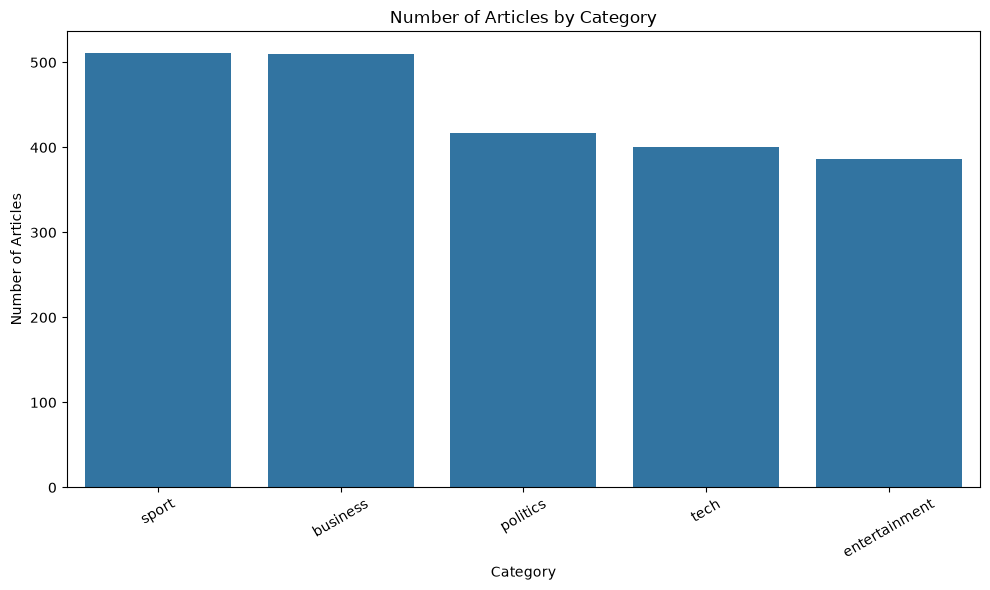

In [90]:
plt.figure(figsize=(10, 6))

sns.countplot(
    data=df,
    x="category",
    order=df["category"].value_counts().index
)

plt.title("Number of Articles by Category")
plt.xlabel("Category")
plt.ylabel("Number of Articles")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

# Distribucija dužine članaka

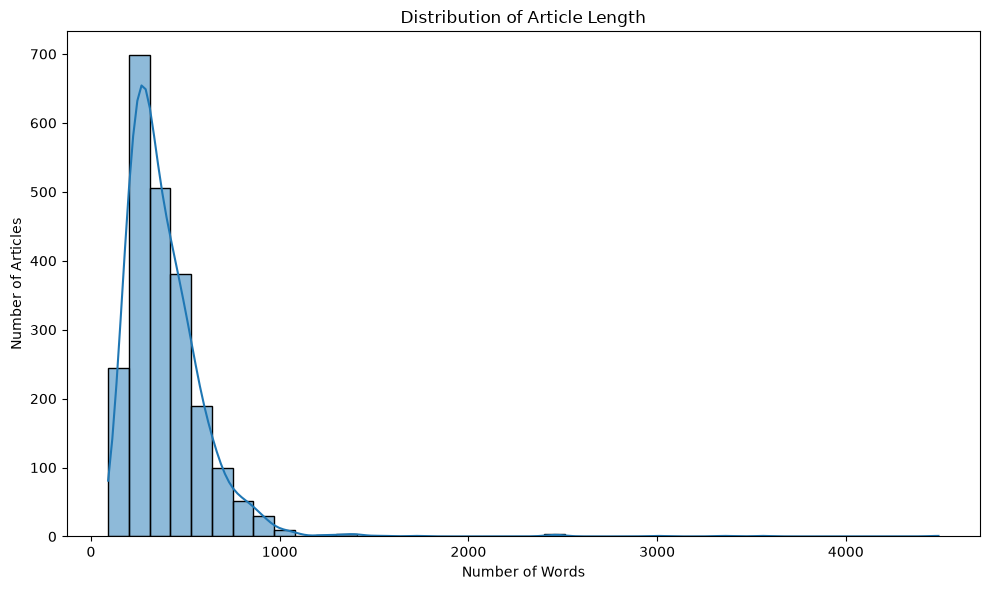

In [91]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="article_words",
    bins=40,
    kde=True
)

plt.title("Distribution of Article Length")
plt.xlabel("Number of Words")
plt.ylabel("Number of Articles")
plt.tight_layout()
plt.show()

# Distribucija dužine sažetaka

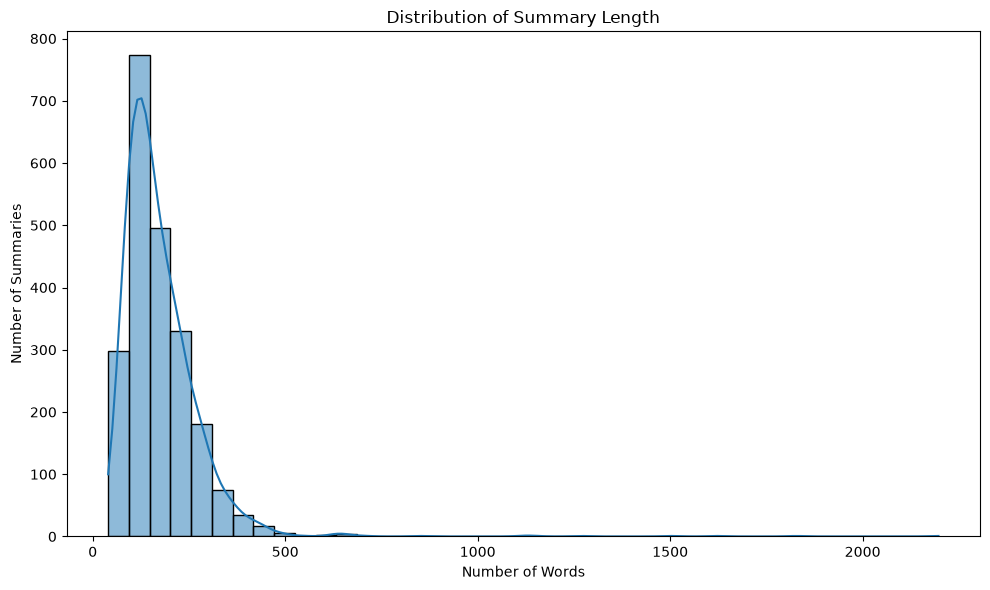

In [92]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="summary_words",
    bins=40,
    kde=True
)

plt.title("Distribution of Summary Length")
plt.xlabel("Number of Words")
plt.ylabel("Number of Summaries")
plt.tight_layout()
plt.show()

# Odnos sažetka i originalnog članka

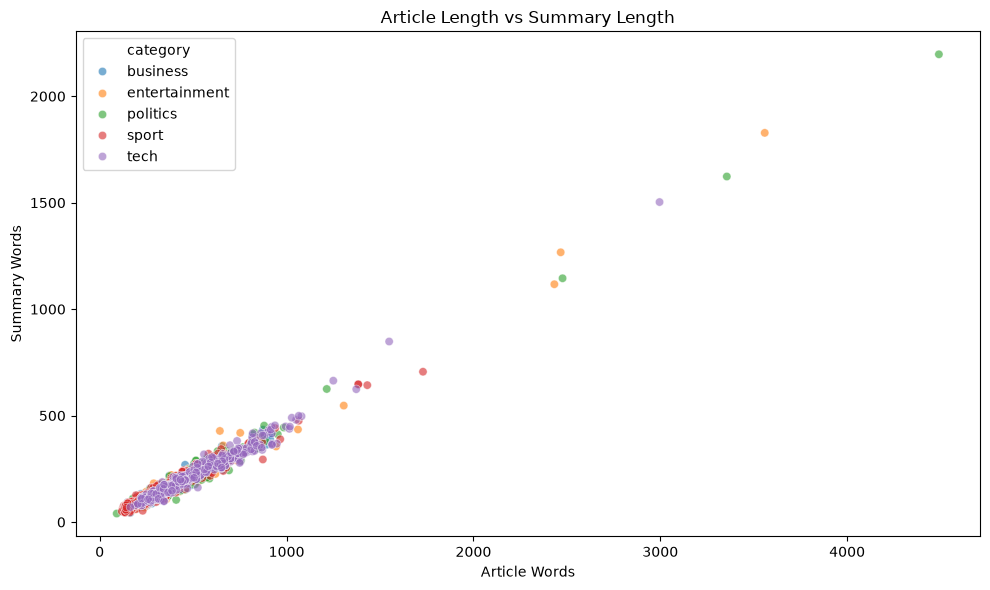

In [93]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="article_words",
    y="summary_words",
    hue="category",
    alpha=0.6
)

plt.title("Article Length vs Summary Length")
plt.xlabel("Article Words")
plt.ylabel("Summary Words")
plt.tight_layout()
plt.show()

# Provera nedostajućih vrednosti

In [94]:
missing_summary = pd.DataFrame({
    "missing_values": df.isnull().sum(),
    "missing_percentage": df.isnull().mean() * 100
})

missing_summary

,missing_values,missing_percentage
category,0,0.0
file_name,0,0.0
article,0,0.0
summary,0,0.0
article_words,0,0.0
summary_words,0,0.0
article_characters,0,0.0
summary_characters,0,0.0
article_sentences,0,0.0
summary_sentences,0,0.0


# Vizuealizacija nedostajućih vrednosti

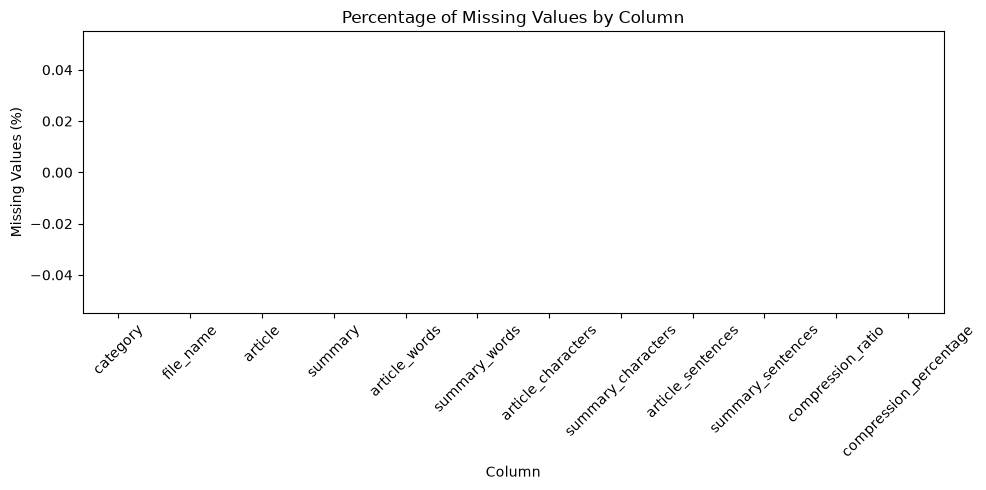

In [95]:
plt.figure(figsize=(10, 5))

missing_percentages = df.isnull().mean() * 100

sns.barplot(
    x=missing_percentages.index,
    y=missing_percentages.values
)

plt.title("Percentage of Missing Values by Column")
plt.xlabel("Column")
plt.ylabel("Missing Values (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Provera duplikata

In [96]:
print("Number of duplicate rows:", df.duplicated().sum())
print("Duplicate articles:", df["article"].duplicated().sum())
print("Duplicate summaries:", df["summary"].duplicated().sum())

Number of duplicate rows: 0
Duplicate articles: 98
Duplicate summaries: 144


# Provera duplikata po kategorijama

In [97]:
duplicate_articles = (
    df[df["article"].duplicated(keep=False)]
    .sort_values("article")
)

duplicate_articles[
    ["category", "file_name", "article"]
].head(20)

article_duplicate_categories = (
    duplicate_articles
    .groupby("article")["category"]
    .nunique()
    .value_counts()
    .sort_index()
)

article_duplicate_categories

category
1    98
Name: count, dtype: int64

# Provera duplikata sažetaka

In [98]:
duplicate_summaries = (
    df[df["summary"].duplicated(keep=False)]
    .sort_values("summary")
)

duplicate_summaries[
    ["category", "file_name", "summary"]
].head(20)

summary_duplicate_categories = (
    duplicate_summaries
    .groupby("summary")["category"]
    .nunique()
    .value_counts()
    .sort_index()
)

summary_duplicate_categories

category
1    144
Name: count, dtype: int64

### Analiza duplikata

U skupu podataka nije pronađen nijedan potpuno identičan red.

Međutim, pronađeno je 98 dupliranih tekstova članaka i 144 duplirana teksta sažetaka. Dodatnom analizom utvrđeno je da se svi duplirani članci i sažeci pojavljuju unutar svojih kategorija, odnosno da nisu pronađeni duplikati koji pripadaju različitim kategorijama.

Duplikati se u ovoj fazi ne uklanjaju automatski. Njihovo postojanje će biti uzeto u obzir prilikom podele podataka na train, validation i test skupove, kao i prilikom cross-validacije, kako bi se izbeglo curenje podataka između skupova.

# Broj različitih članaka

In [99]:
unique_articles = df["article"].nunique()
unique_summaries = df["summary"].nunique()

print("Total records:", len(df))
print("Unique articles:", unique_articles)
print("Unique summaries:", unique_summaries)

Total records: 2225
Unique articles: 2127
Unique summaries: 2081


# Provera raspodele kategorija

In [100]:
category_summary = (
    df.groupby("category")
    .agg(
        articles=("article", "count"),
        unique_articles=("article", "nunique"),
        summaries=("summary", "count"),
        unique_summaries=("summary", "nunique"),
    )
)

category_summary

,articles,unique_articles,summaries,unique_summaries
category,,,,
business,510,503,510,500
entertainment,386,369,386,364
politics,417,403,417,395
sport,511,505,511,492
tech,401,347,401,330


# Korelaciona matrica

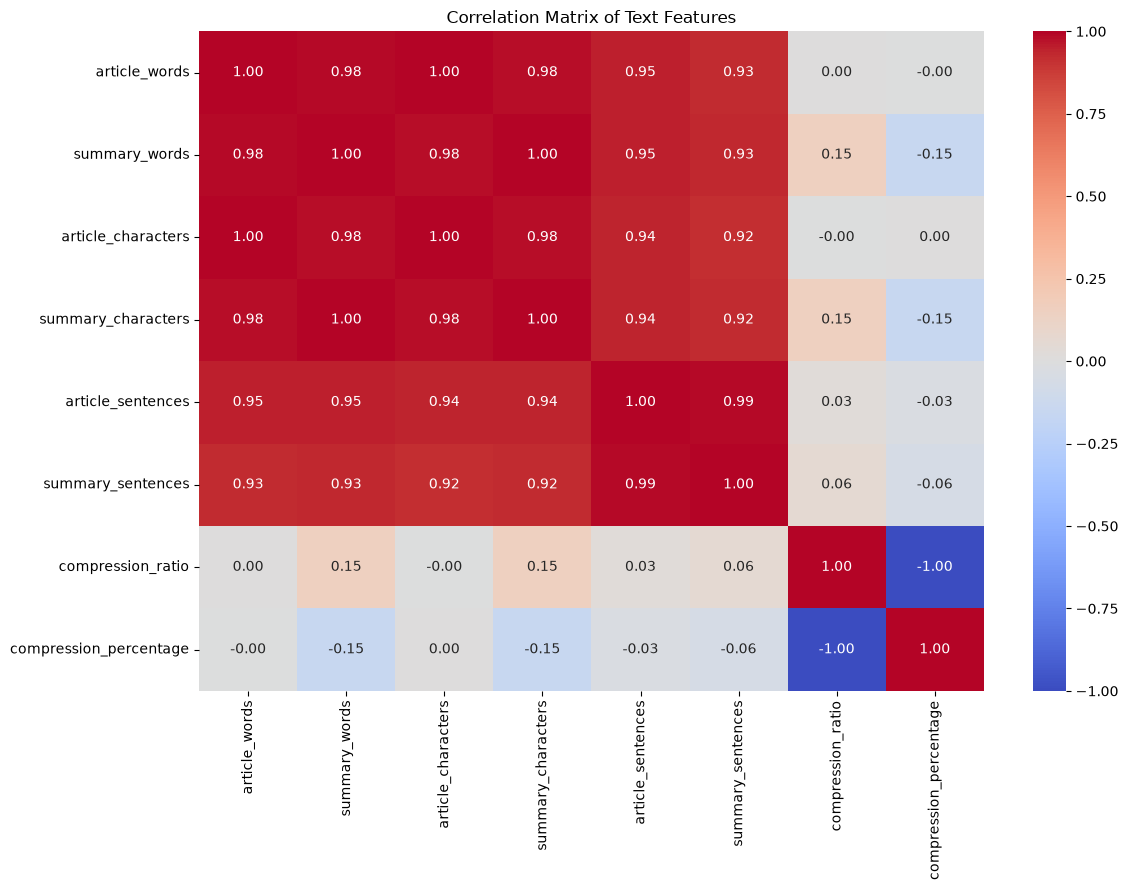

In [101]:
correlation_columns = [
    "article_words",
    "summary_words",
    "article_characters",
    "summary_characters",
    "article_sentences",
    "summary_sentences",
    "compression_ratio",
    "compression_percentage",
]

correlation_matrix = df[correlation_columns].corr()

plt.figure(figsize=(12, 9))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix of Text Features")
plt.tight_layout()
plt.show()

# Dužina članaka po kategorijama

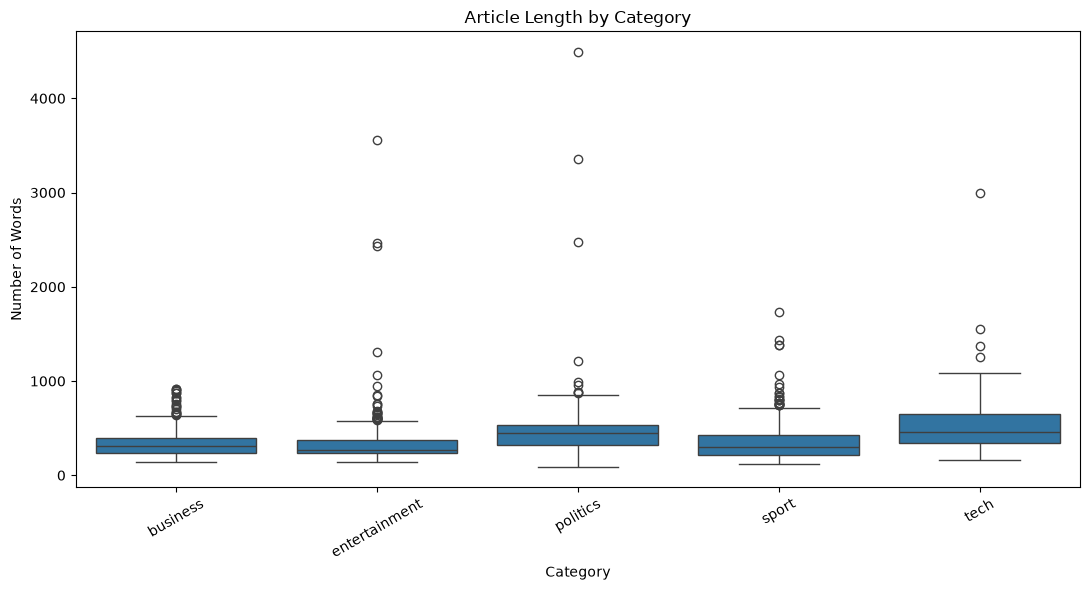

In [102]:
plt.figure(figsize=(11, 6))

sns.boxplot(
    data=df,
    x="category",
    y="article_words"
)

plt.title("Article Length by Category")
plt.xlabel("Category")
plt.ylabel("Number of Words")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

# Dužina sažetaka po kategoriji

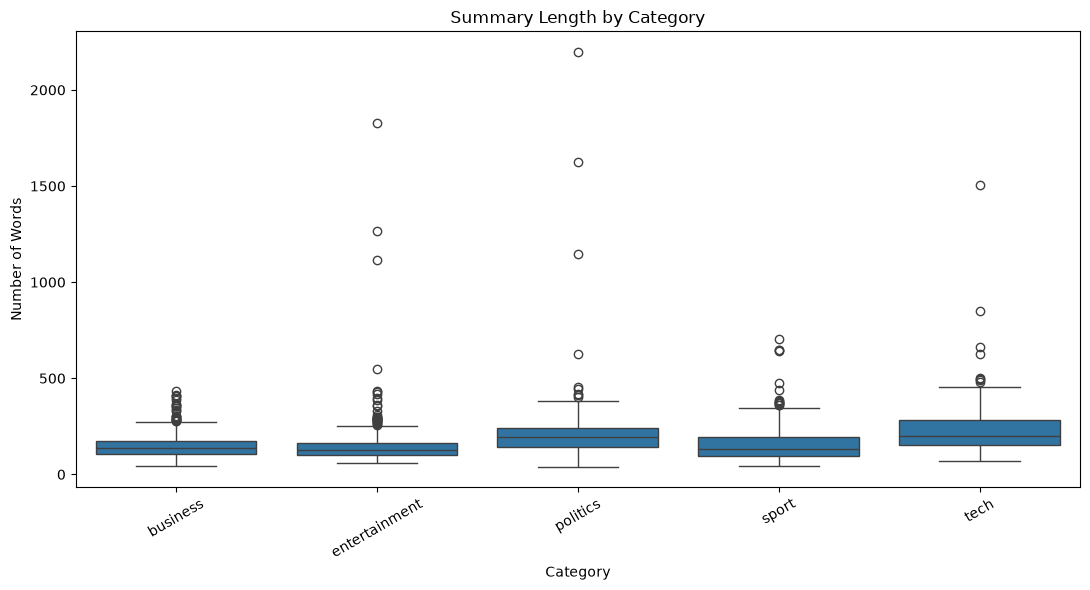

In [103]:
plt.figure(figsize=(11, 6))

sns.boxplot(
    data=df,
    x="category",
    y="summary_words"
)

plt.title("Summary Length by Category")
plt.xlabel("Category")
plt.ylabel("Number of Words")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

# Prosečne vrednosti po kategoriji

In [104]:
category_statistics = (
    df.groupby("category")[
        [
            "article_words",
            "summary_words",
            "article_sentences",
            "summary_sentences",
            "compression_ratio",
        ]
    ]
    .mean()
    .round(2)
)

category_statistics

,article_words,summary_words,article_sentences,summary_sentences,compression_ratio
category,,,,,
business,338.31,149.84,18.68,8.17,0.44
entertainment,339.95,153.93,17.39,7.48,0.45
politics,461.50,206.47,21.56,9.04,0.45
sport,341.14,154.37,17.86,7.52,0.46
tech,513.25,227.04,25.21,10.44,0.44


# Primeri članaka i referentnih sažetaka

In [105]:
for _, row in df.sample(3, random_state=42).iterrows():
    print("=" * 100)
    print(f"Category: {row['category']}")
    print(f"File: {row['file_name']}")
    print("\nARTICLE:\n")
    print(row["article"][:1500])
    print("\nREFERENCE SUMMARY:\n")
    print(row["summary"][:1000])
    print()

Category: business
File: 415.txt

ARTICLE:

UK house prices dip in November

UK house prices dipped slightly in November, the Office of the Deputy Prime Minister (ODPM) has said.

The average house price fell marginally to £180,226, from £180,444 in October. Recent evidence has suggested that the UK housing market is slowing after interest rate increases, and economists forecast a drop in prices during 2005. But while the monthly figures may hint at a cooling of the market, annual house price inflation is still strong, up 13.8% in the year to November. Economists, however, forecast that ODPM figures are likely to show a weakening in annual house price growth in coming months. "Overall, the housing market activity is slowing down and that is backed up by the mortgage lending and the mortgage approvals data," said Mark Miller, at HBOS Treasury Services. "The ODPM data is a fairly lagging indicator."

The figures come after the Bank of England said the number of mortgages approved in the 

# Čuvanje EDA podataka

In [106]:
processed_dir = PROJECT_ROOT / "data" / "processed"
processed_dir.mkdir(parents=True, exist_ok=True)

output_path = processed_dir / "bbc_news_features.csv"

df.to_csv(output_path, index=False)

print(f"Saved dataset to: {output_path}")

Saved dataset to: c:\Users\conji\OneDrive\Desktop\BBC-News-Summary\data\processed\bbc_news_features.csv
